# Linear Regression from First Principles

This notebook is a tutorial on the **ordinary least squares (OLS)** linear regression model. We derive each quantity mathematically and then compute it directly with `numpy`, so that nothing is hidden inside a library call. `scipy.stats` is used only for the quantiles and tail probabilities of the $t$, $F$ and normal distributions.

**Contents**

1. The linear model and its assumptions
2. Simulating data with known parameters
3. The design matrix
4. The OLS estimator
5. Fitted values, residuals and the hat matrix
6. Estimating the error variance
7. Sampling distribution of $\hat{\boldsymbol\beta}$: standard errors, $t$-tests and confidence intervals
8. Goodness of fit: $R^2$ and the $F$-test
9. Confidence intervals for the mean response vs. prediction intervals
10. Residual diagnostics
11. A Monte Carlo check of the theory

**Notation.** Bold lower-case letters are column vectors, bold upper-case letters are matrices, $^\top$ denotes transpose, $\mathbf I_n$ is the $n\times n$ identity, and $\operatorname{tr}(\cdot)$ is the trace. Hats ($\hat{\ }$) denote estimators.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. The linear model and its assumptions

We observe $n$ pairs $(x_i, y_i)$, $i = 1, \dots, n$. The **simple linear regression model** states that

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad i = 1, \dots, n,
$$

where $\beta_0$ (intercept) and $\beta_1$ (slope) are unknown fixed parameters and $\varepsilon_i$ is an unobserved random error. Stacking the $n$ equations gives the **matrix form**, which generalises directly to $p-1$ predictors:

$$
\mathbf y = \mathbf X \boldsymbol\beta + \boldsymbol\varepsilon,
\qquad
\mathbf y = \begin{pmatrix} y_1 \\ \vdots \\ y_n \end{pmatrix},\;
\mathbf X = \begin{pmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_n \end{pmatrix},\;
\boldsymbol\beta = \begin{pmatrix} \beta_0 \\ \beta_1 \end{pmatrix},\;
\boldsymbol\varepsilon = \begin{pmatrix} \varepsilon_1 \\ \vdots \\ \varepsilon_n \end{pmatrix}.
$$

Here $\mathbf X \in \mathbb R^{n\times p}$ is the **design matrix**, with $p = 2$ columns (parameters) in the simple case.

### Assumptions

Throughout, we treat $\mathbf X$ as fixed (equivalently, all statements are *conditional on* $\mathbf X$).

| | Assumption | Statement | Needed for |
|---|---|---|---|
| A1 | Linearity | $\mathbb E[\mathbf y] = \mathbf X\boldsymbol\beta$ | everything |
| A2 | Full rank | $\operatorname{rank}(\mathbf X) = p$ (no column is a linear combination of the others; requires $n \ge p$) | $\hat{\boldsymbol\beta}$ to be unique |
| A3 | Zero-mean errors | $\mathbb E[\boldsymbol\varepsilon] = \mathbf 0$ | unbiasedness |
| A4 | Spherical errors | $\operatorname{Var}(\boldsymbol\varepsilon) = \sigma^2 \mathbf I_n$, i.e. constant variance (*homoscedasticity*) and zero correlation between errors | standard errors, Gauss–Markov |
| A5 | Normality | $\boldsymbol\varepsilon \sim \mathcal N_n(\mathbf 0, \sigma^2\mathbf I_n)$ | *exact* $t$ and $F$ inference in finite samples |

A1–A4 are the **Gauss–Markov assumptions**. A5 is stronger than A3–A4 together. Under A5 the errors are not only uncorrelated but independent, and every statistic below has a known exact distribution. Without A5, the $t$ and $F$ results still hold approximately for large $n$ by the central limit theorem.

## 2. Simulating data with known parameters

To check our estimators against the truth, we **simulate** data from the model with parameters we choose ourselves:

$$
\beta_0 = 2,\quad \beta_1 = 0.5,\quad \sigma = 1,\quad n = 100,\qquad x_i \sim \text{Uniform}(0, 10),\quad \varepsilon_i \overset{\text{iid}}{\sim} \mathcal N(0, \sigma^2).
$$

With real data the true parameters are unknown, so this is a luxury that lets us *verify* the theory. The random number generator is seeded so that the results are reproducible.

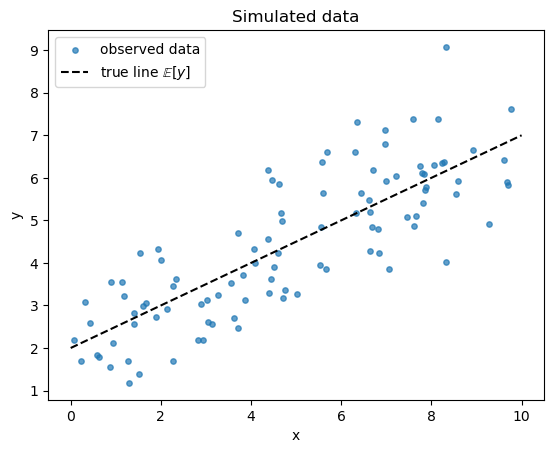

In [4]:
rng = np.random.default_rng(seed=42)

n = 100                              # sample size
beta_true = np.array([2.0, 0.5])     # (intercept, slope)
sigma_true = 1.0                     # standard deviation of the errors

x = rng.uniform(0, 10, size=n)
epsilon = rng.normal(0, sigma_true, size=n)
y = beta_true[0] + beta_true[1] * x + epsilon

fig, ax = plt.subplots()
ax.scatter(x, y, s=15, alpha=0.7, label='observed data')
ax.plot([0, 10], beta_true[0] + beta_true[1] * np.array([0, 10]), 'k--', label='true line $\\mathbb{E}[y]$')
ax.set(xlabel='x', ylabel='y', title='Simulated data')
ax.legend()
plt.show()

## 3. The design matrix

The column of ones in $\mathbf X$ is what makes $\beta_0$ an intercept: $(\mathbf X\boldsymbol\beta)_i = 1\cdot\beta_0 + x_i\beta_1$. We confirm assumption A2 by checking that $\mathbf X$ has full column rank.

In [5]:
X = np.column_stack([np.ones(n), x])
p = X.shape[1]                       # number of parameters

print('First five rows of X:')
print(X[:5])
print(f'\nShape of X: {X.shape},  rank(X) = {np.linalg.matrix_rank(X)}  (p = {p})')

First five rows of X:
[[1.         7.73956049]
 [1.         4.3887844 ]
 [1.         8.5859792 ]
 [1.         6.97368029]
 [1.         0.94177348]]

Shape of X: (100, 2),  rank(X) = 2  (p = 2)


## 4. The OLS estimator

### Definition

The OLS estimator chooses $\boldsymbol\beta$ to minimise the **residual sum of squares**

$$
S(\boldsymbol\beta) = \sum_{i=1}^n (y_i - \mathbf x_i^\top\boldsymbol\beta)^2 = (\mathbf y - \mathbf X\boldsymbol\beta)^\top(\mathbf y - \mathbf X\boldsymbol\beta),
$$

where $\mathbf x_i^\top$ is the $i$-th row of $\mathbf X$.

### Derivation

Expanding, $S(\boldsymbol\beta) = \mathbf y^\top\mathbf y - 2\boldsymbol\beta^\top\mathbf X^\top\mathbf y + \boldsymbol\beta^\top\mathbf X^\top\mathbf X\boldsymbol\beta$. Setting the gradient to zero,

$$
\frac{\partial S}{\partial \boldsymbol\beta} = -2\mathbf X^\top\mathbf y + 2\mathbf X^\top\mathbf X\boldsymbol\beta = \mathbf 0
\quad\Longrightarrow\quad
\mathbf X^\top\mathbf X\,\hat{\boldsymbol\beta} = \mathbf X^\top\mathbf y .
$$

These are the **normal equations**. Under A2, $\mathbf X^\top\mathbf X$ is invertible, so

$$
\boxed{\hat{\boldsymbol\beta} = (\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y.}
$$

This stationary point is the unique global minimum. The Hessian $\partial^2 S/\partial\boldsymbol\beta\,\partial\boldsymbol\beta^\top = 2\mathbf X^\top\mathbf X$ is positive definite, because $\mathbf v^\top\mathbf X^\top\mathbf X\mathbf v = \lVert\mathbf X\mathbf v\rVert^2 > 0$ for every $\mathbf v \neq \mathbf 0$ when $\mathbf X$ has full column rank. So $S$ is strictly convex.

### The simple-regression special case

With one predictor, solving the two normal equations by hand gives the familiar formulas

$$
\hat\beta_1 = \frac{S_{xy}}{S_{xx}} = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sum_i (x_i-\bar x)^2},
\qquad
\hat\beta_0 = \bar y - \hat\beta_1 \bar x .
$$

The second equation shows that the fitted line always passes through the point of means $(\bar x, \bar y)$.

### A numerical remark

We do **not** compute $(\mathbf X^\top\mathbf X)^{-1}$ explicitly to obtain $\hat{\boldsymbol\beta}$. Forming $\mathbf X^\top\mathbf X$ squares the condition number of $\mathbf X$, which amplifies rounding error. `np.linalg.lstsq` minimises $\lVert\mathbf y - \mathbf X\boldsymbol\beta\rVert^2$ directly using an orthogonal (SVD) decomposition of $\mathbf X$, which is numerically stable. Below we confirm that it agrees with the closed-form formulas.

In [6]:
beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)

# Closed-form simple-regression formulas, as a check
x_bar, y_bar = x.mean(), y.mean()
S_xx = np.sum((x - x_bar) ** 2)
S_xy = np.sum((x - x_bar) * (y - y_bar))
beta1_closed = S_xy / S_xx
beta0_closed = y_bar - beta1_closed * x_bar

print(f'lstsq:        beta0_hat = {beta_hat[0]:.4f},  beta1_hat = {beta_hat[1]:.4f}')
print(f'closed form:  beta0_hat = {beta0_closed:.4f},  beta1_hat = {beta1_closed:.4f}')
print(f'true values:  beta0     = {beta_true[0]:.4f},  beta1     = {beta_true[1]:.4f}')
print('Agree:', np.allclose(beta_hat, [beta0_closed, beta1_closed]))

lstsq:        beta0_hat = 1.9487,  beta1_hat = 0.5077
closed form:  beta0_hat = 1.9487,  beta1_hat = 0.5077
true values:  beta0     = 2.0000,  beta1     = 0.5000
Agree: True


### Properties of $\hat{\boldsymbol\beta}$

Substituting $\mathbf y = \mathbf X\boldsymbol\beta + \boldsymbol\varepsilon$ into the estimator gives the key identity

$$
\hat{\boldsymbol\beta} = (\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top(\mathbf X\boldsymbol\beta + \boldsymbol\varepsilon) = \boldsymbol\beta + (\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\boldsymbol\varepsilon .
$$

From it we obtain:

* **Unbiasedness** (A1–A3): $\mathbb E[\hat{\boldsymbol\beta}] = \boldsymbol\beta + (\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\,\mathbb E[\boldsymbol\varepsilon] = \boldsymbol\beta$.
* **Covariance** (A1–A4): using $\operatorname{Var}(\mathbf A\boldsymbol\varepsilon) = \mathbf A\operatorname{Var}(\boldsymbol\varepsilon)\mathbf A^\top$,
$$
\operatorname{Var}(\hat{\boldsymbol\beta}) = (\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top(\sigma^2\mathbf I_n)\mathbf X(\mathbf X^\top\mathbf X)^{-1} = \sigma^2(\mathbf X^\top\mathbf X)^{-1}.
$$
In simple regression, the slope's diagonal element reduces to $\operatorname{Var}(\hat\beta_1) = \sigma^2/S_{xx}$. The slope is estimated more precisely when the errors are smaller, when $n$ is larger, and when the $x_i$ are more spread out.
* **Gauss–Markov theorem** (A1–A4): among all estimators that are *linear* in $\mathbf y$ and *unbiased*, OLS has the smallest variance. Formally, $\operatorname{Var}(\tilde{\boldsymbol\beta}) - \operatorname{Var}(\hat{\boldsymbol\beta})$ is positive semi-definite for any such $\tilde{\boldsymbol\beta}$. OLS is therefore the **BLUE** (best linear unbiased estimator).
* **Exact distribution** (A1–A5): $\hat{\boldsymbol\beta}$ is a linear transformation of the Gaussian vector $\boldsymbol\varepsilon$, so
$$
\hat{\boldsymbol\beta} \sim \mathcal N_p\!\left(\boldsymbol\beta,\; \sigma^2(\mathbf X^\top\mathbf X)^{-1}\right).
$$
Under A5, OLS also coincides with the maximum-likelihood estimator of $\boldsymbol\beta$.

## 5. Fitted values, residuals and the hat matrix

The **fitted values** are $\hat{\mathbf y} = \mathbf X\hat{\boldsymbol\beta} = \mathbf H\mathbf y$, where

$$
\mathbf H = \mathbf X(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top
$$

is the **hat matrix** (it "puts the hat on $\mathbf y$"). The **residuals** are $\mathbf e = \mathbf y - \hat{\mathbf y} = (\mathbf I_n - \mathbf H)\mathbf y =: \mathbf M\mathbf y$.

Geometrically, $\mathbf H$ is the **orthogonal projection** onto the column space of $\mathbf X$, and $\mathbf M$ projects onto its orthogonal complement. The following properties follow:

1. $\mathbf H$ and $\mathbf M$ are symmetric and idempotent ($\mathbf H^2 = \mathbf H$, $\mathbf M^2 = \mathbf M$), and $\mathbf H\mathbf M = \mathbf 0$.
2. $\operatorname{tr}(\mathbf H) = \operatorname{tr}\big((\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf X\big) = \operatorname{tr}(\mathbf I_p) = p$, so $\operatorname{tr}(\mathbf M) = n - p$.
3. $\mathbf X^\top\mathbf e = \mathbf 0$: the residuals are orthogonal to every column of $\mathbf X$. This is just a restatement of the normal equations. Because the first column is all ones, $\sum_i e_i = 0$.
4. $\mathbf e = \mathbf M\mathbf y = \mathbf M(\mathbf X\boldsymbol\beta + \boldsymbol\varepsilon) = \mathbf M\boldsymbol\varepsilon$, since $\mathbf M\mathbf X = \mathbf 0$.

The diagonal elements $h_{ii}$ are the **leverages**. They satisfy $0 \le h_{ii} \le 1$ and $\sum_i h_{ii} = p$, and they measure how far $\mathbf x_i$ lies from the centre of the design.

We verify each property numerically. (Forming the $n\times n$ matrix $\mathbf H$ is fine for $n = 100$, but it would be wasteful for large $n$.)

In [7]:
y_hat = X @ beta_hat
residuals = y - y_hat

XtX_inv = np.linalg.inv(X.T @ X)     # 2x2 and well conditioned here; used for variances
H = X @ XtX_inv @ X.T
M = np.eye(n) - H
leverage = np.diag(H)

print('H symmetric:         ', np.allclose(H, H.T))
print('H idempotent:        ', np.allclose(H @ H, H))
print('HM = 0:              ', np.allclose(H @ M, 0))
print(f'trace(H) = {np.trace(H):.6f}   (p = {p})')
print(f'trace(M) = {np.trace(M):.6f}  (n - p = {n - p})')
print('X^T e = ', X.T @ residuals, '  (zero up to rounding)')
print(f'sum of residuals = {residuals.sum():.2e}')

H symmetric:          True
H idempotent:         True
HM = 0:               True
trace(H) = 2.000000   (p = 2)
trace(M) = 98.000000  (n - p = 98)
X^T e =  [-1.86073379e-13 -8.47417771e-13]   (zero up to rounding)
sum of residuals = -1.85e-13


## 6. Estimating the error variance $\sigma^2$

The **residual sum of squares** is $\mathrm{RSS} = \mathbf e^\top\mathbf e = \boldsymbol\varepsilon^\top\mathbf M\boldsymbol\varepsilon$, because $\mathbf M$ is symmetric and idempotent. Using the identity $\mathbb E[\boldsymbol\varepsilon^\top\mathbf A\boldsymbol\varepsilon] = \operatorname{tr}(\mathbf A\operatorname{Var}(\boldsymbol\varepsilon))$ for a zero-mean vector,

$$
\mathbb E[\mathrm{RSS}] = \operatorname{tr}(\mathbf M\,\sigma^2\mathbf I_n) = \sigma^2(n - p).
$$

Hence

$$
\boxed{s^2 = \hat\sigma^2 = \frac{\mathrm{RSS}}{n - p}}
$$

is an **unbiased** estimator of $\sigma^2$. The quantity $n - p$ is the **residual degrees of freedom**: estimating $p$ parameters "uses up" $p$ dimensions, and the residuals are confined to an $(n-p)$-dimensional subspace. The maximum-likelihood estimator $\mathrm{RSS}/n$ is biased downward for this reason. $s = \sqrt{s^2}$ is called the **residual standard error**.

Under A5, $\mathrm{RSS}/\sigma^2 = \boldsymbol\varepsilon^\top\mathbf M\boldsymbol\varepsilon/\sigma^2 \sim \chi^2_{n-p}$, because $\mathbf M$ is an idempotent matrix of rank $n-p$. Moreover, $\hat{\boldsymbol\beta}$ depends on $\boldsymbol\varepsilon$ only through $\mathbf X^\top\boldsymbol\varepsilon$, and $\mathbf e = \mathbf M\boldsymbol\varepsilon$. These two Gaussian vectors are uncorrelated ($\mathbf X^\top\mathbf M = \mathbf 0$), so they are **independent**, which means $\hat{\boldsymbol\beta}$ and $s^2$ are independent. This fact is what makes the $t$-statistic in the next section work.

In [8]:
RSS = residuals @ residuals
df_resid = n - p
s2 = RSS / df_resid
s = np.sqrt(s2)

print(f'RSS = {RSS:.4f}')
print(f'residual degrees of freedom = {df_resid}')
print(f's^2 = {s2:.4f}   (true sigma^2 = {sigma_true**2:.4f})')
print(f's   = {s:.4f}   (true sigma   = {sigma_true:.4f})')
print(f'MLE RSS/n = {RSS / n:.4f}  (biased downward)')

RSS = 95.8864
residual degrees of freedom = 98
s^2 = 0.9784   (true sigma^2 = 1.0000)
s   = 0.9892   (true sigma   = 1.0000)
MLE RSS/n = 0.9589  (biased downward)


## 7. Inference on $\boldsymbol\beta$: standard errors, $t$-tests and confidence intervals

### Standard errors

Replacing the unknown $\sigma^2$ in $\operatorname{Var}(\hat{\boldsymbol\beta})$ by $s^2$ gives the estimated covariance matrix $\widehat{\operatorname{Var}}(\hat{\boldsymbol\beta}) = s^2(\mathbf X^\top\mathbf X)^{-1}$. The **standard error** of $\hat\beta_j$ is

$$
\operatorname{SE}(\hat\beta_j) = s\sqrt{\big[(\mathbf X^\top\mathbf X)^{-1}\big]_{jj}} .
$$

### The $t$-statistic

Under A1–A5,

$$
T_j = \frac{\hat\beta_j - \beta_j}{\operatorname{SE}(\hat\beta_j)}
= \frac{(\hat\beta_j - \beta_j)\big/\big(\sigma\sqrt{[(\mathbf X^\top\mathbf X)^{-1}]_{jj}}\big)}{\sqrt{\dfrac{\mathrm{RSS}/\sigma^2}{n-p}}}
\sim \frac{\mathcal N(0,1)}{\sqrt{\chi^2_{n-p}/(n-p)}} = t_{n-p},
$$

because the numerator and denominator are independent (Section 6). This result is exact in finite samples, and it is a **pivot**: its distribution does not depend on any unknown parameter.

### Hypothesis test

To test $H_0\colon \beta_j = 0$ against $H_1\colon \beta_j \neq 0$, compute $t_j = \hat\beta_j/\operatorname{SE}(\hat\beta_j)$. The two-sided **$p$-value** is

$$
p_j = \Pr\big(|T| \ge |t_j|\big) = 2\,\Pr\big(T \ge |t_j|\big), \qquad T \sim t_{n-p}.
$$

The $p$-value is the probability, **computed assuming $H_0$ is true**, of a test statistic at least as extreme as the one observed. It is *not* the probability that $H_0$ is true. We reject $H_0$ at level $\alpha$ when $p_j < \alpha$. This procedure has type-I error rate exactly $\alpha$ under the model assumptions.

### Confidence interval

Inverting the pivot gives the $100(1-\alpha)\%$ confidence interval

$$
\hat\beta_j \pm t_{n-p,\,1-\alpha/2}\,\operatorname{SE}(\hat\beta_j),
$$

where $t_{n-p,\,1-\alpha/2}$ is the $1-\alpha/2$ quantile of $t_{n-p}$. The interpretation is frequentist. $\beta_j$ is fixed and the interval is random, and if the experiment were repeated many times, $100(1-\alpha)\%$ of the intervals constructed this way would contain $\beta_j$. A single computed interval either contains $\beta_j$ or it does not. Section 11 checks this coverage empirically.

In [9]:
cov_beta = s2 * XtX_inv
se = np.sqrt(np.diag(cov_beta))
t_stats = beta_hat / se
p_values = 2 * stats.t.sf(np.abs(t_stats), df_resid)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df_resid)
ci_lower = beta_hat - t_crit * se
ci_upper = beta_hat + t_crit * se


def print_coefficient_row(name, j):
    print(f'{name:<10}{beta_hat[j]:>10.4f}{se[j]:>10.4f}{t_stats[j]:>10.3f}'
          f'{p_values[j]:>12.3g}   [{ci_lower[j]:.4f}, {ci_upper[j]:.4f}]')


print(f'{"":<10}{"estimate":>10}{"SE":>10}{"t":>10}{"p-value":>12}   95% CI')
print_coefficient_row('intercept', 0)
print_coefficient_row('slope', 1)
print(f'\nt critical value t_({df_resid}, 0.975) = {t_crit:.4f}')

            estimate        SE         t     p-value   95% CI
intercept     1.9487    0.2026     9.617     8.2e-16   [1.5466, 2.3508]
slope         0.5077    0.0363    13.973    4.66e-25   [0.4356, 0.5798]

t critical value t_(98, 0.975) = 1.9845


## 8. Goodness of fit: $R^2$ and the overall $F$-test

### Sum-of-squares decomposition

Define the **total**, **explained** and **residual** sums of squares:

$$
\mathrm{TSS} = \sum_i (y_i - \bar y)^2, \qquad
\mathrm{ESS} = \sum_i (\hat y_i - \bar y)^2, \qquad
\mathrm{RSS} = \sum_i (y_i - \hat y_i)^2 .
$$

When the model contains an intercept, $\mathrm{TSS} = \mathrm{ESS} + \mathrm{RSS}$. To see this, write $y_i - \bar y = (\hat y_i - \bar y) + e_i$ and expand. The cross term $\sum_i(\hat y_i - \bar y)e_i = \hat{\mathbf y}^\top\mathbf e - \bar y\sum_i e_i$ vanishes, because $\hat{\mathbf y} = \mathbf H\mathbf y$ is orthogonal to $\mathbf e$ and the residuals sum to zero.

### Coefficient of determination

$$
R^2 = \frac{\mathrm{ESS}}{\mathrm{TSS}} = 1 - \frac{\mathrm{RSS}}{\mathrm{TSS}} \in [0, 1]
$$

is the proportion of the sample variation in $y$ that the model accounts for. In simple regression, $R^2 = r_{xy}^2$, the squared sample correlation. $R^2$ can never decrease when a predictor is added, so the **adjusted** version penalises extra parameters:

$$
\bar R^2 = 1 - \frac{\mathrm{RSS}/(n-p)}{\mathrm{TSS}/(n-1)} .
$$

$R^2$ measures fit, *not* model validity. A high $R^2$ does not imply that the assumptions hold or that the relationship is causal.

### Overall $F$-test

To test $H_0\colon \beta_1 = \dots = \beta_{p-1} = 0$ (all slopes zero), use

$$
F = \frac{\mathrm{ESS}/(p-1)}{\mathrm{RSS}/(n-p)} \;\overset{H_0}{\sim}\; F_{p-1,\,n-p}.
$$

Under $H_0$ and A5, $\mathrm{ESS}/\sigma^2 \sim \chi^2_{p-1}$ independently of $\mathrm{RSS}/\sigma^2 \sim \chi^2_{n-p}$. In simple regression ($p = 2$), $F = t_1^2$ and the $F$-test is identical to the two-sided $t$-test on the slope.

In [10]:
TSS = np.sum((y - y_bar) ** 2)
ESS = np.sum((y_hat - y_bar) ** 2)

R2 = 1 - RSS / TSS
adj_R2 = 1 - (RSS / df_resid) / (TSS / (n - 1))
F_stat = (ESS / (p - 1)) / (RSS / df_resid)
F_p_value = stats.f.sf(F_stat, p - 1, df_resid)

print(f'TSS = {TSS:.4f},  ESS + RSS = {ESS + RSS:.4f}')
print(f'R^2          = {R2:.4f}')
print(f'r_xy^2       = {np.corrcoef(x, y)[0, 1] ** 2:.4f}')
print(f'adjusted R^2 = {adj_R2:.4f}')
print(f'F = {F_stat:.3f} on ({p - 1}, {df_resid}) df,  p-value = {F_p_value:.3g}')
print(f't_slope^2 = {t_stats[1] ** 2:.3f}  (equals F)')

TSS = 286.9072,  ESS + RSS = 286.9072
R^2          = 0.6658
r_xy^2       = 0.6658
adjusted R^2 = 0.6624
F = 195.231 on (1, 98) df,  p-value = 4.66e-25
t_slope^2 = 195.231  (equals F)


## 9. Confidence intervals for the mean response vs. prediction intervals

At a new predictor value with row vector $\mathbf x_0^\top = (1, x_0)$, there are two different questions we can ask.

**(a) Where is the mean response $\mu_0 = \mathbb E[y \mid x_0] = \mathbf x_0^\top\boldsymbol\beta$?** The estimator $\hat\mu_0 = \mathbf x_0^\top\hat{\boldsymbol\beta}$ has variance $\sigma^2\,\mathbf x_0^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_0$, so a $100(1-\alpha)\%$ **confidence interval** is

$$
\hat\mu_0 \pm t_{n-p,\,1-\alpha/2}\; s\sqrt{\mathbf x_0^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_0}.
$$

**(b) Where will a *new observation* $y_0 = \mathbf x_0^\top\boldsymbol\beta + \varepsilon_0$ fall?** The new error $\varepsilon_0$ is independent of the data used to fit $\hat{\boldsymbol\beta}$. The prediction error $y_0 - \hat\mu_0$ therefore has variance $\sigma^2\big(1 + \mathbf x_0^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_0\big)$, and the **prediction interval** is

$$
\hat\mu_0 \pm t_{n-p,\,1-\alpha/2}\; s\sqrt{1 + \mathbf x_0^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_0}.
$$

The prediction interval is always wider. As $n \to \infty$, the confidence interval shrinks to zero width, but the prediction interval does not: its width tends to $2\,z_{1-\alpha/2}\,\sigma$ because the irreducible noise $\varepsilon_0$ remains. Both intervals are narrowest at $x_0 = \bar x$ and widen as $x_0$ moves away from it. Extrapolating beyond the observed range of $x$ also assumes that linearity continues to hold there, which the data cannot confirm.

In the code, the quadratic form $\mathbf x_0^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_0$ is evaluated for every grid point at once, as a row-wise sum.

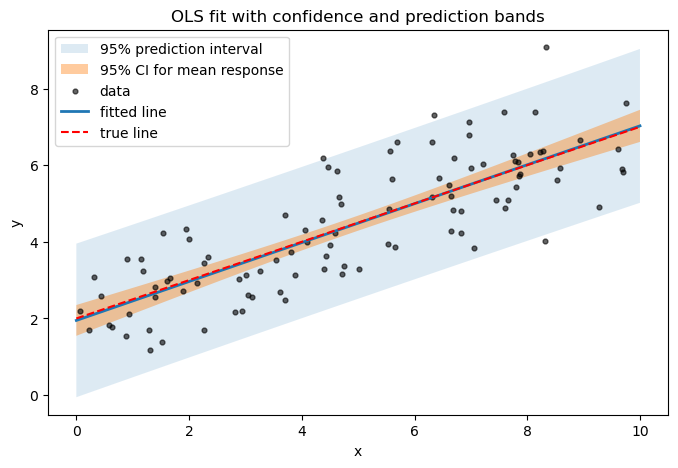

Fraction of observed points inside their 95% prediction interval: 0.96


In [11]:
x_grid = np.linspace(0, 10, 200)
X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
mu_hat_grid = X_grid @ beta_hat
quad_form = np.sum((X_grid @ XtX_inv) * X_grid, axis=1)   # x0^T (X^T X)^{-1} x0 for each row

ci_half_width = t_crit * s * np.sqrt(quad_form)
pi_half_width = t_crit * s * np.sqrt(1 + quad_form)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(x_grid, mu_hat_grid - pi_half_width, mu_hat_grid + pi_half_width,
                alpha=0.15, label='95% prediction interval')
ax.fill_between(x_grid, mu_hat_grid - ci_half_width, mu_hat_grid + ci_half_width,
                alpha=0.4, label='95% CI for mean response')
ax.scatter(x, y, s=12, color='k', alpha=0.6, label='data')
ax.plot(x_grid, mu_hat_grid, lw=2, label='fitted line')
ax.plot(x_grid, X_grid @ beta_true, 'r--', lw=1.5, label='true line')
ax.set(xlabel='x', ylabel='y', title='OLS fit with confidence and prediction bands')
ax.legend()
plt.show()

inside = np.abs(y - y_hat) <= t_crit * s * np.sqrt(1 + leverage)
print(f'Fraction of observed points inside their 95% prediction interval: {inside.mean():.2f}')

## 10. Residual diagnostics

The inference above is only valid if the assumptions hold, and the residuals are our window onto the unobservable errors. The raw residuals are not exactly homoscedastic even when the errors are: $\operatorname{Var}(\mathbf e) = \operatorname{Var}(\mathbf M\boldsymbol\varepsilon) = \sigma^2\mathbf M$, so $\operatorname{Var}(e_i) = \sigma^2(1 - h_{ii})$. We therefore use **standardised residuals**

$$
r_i = \frac{e_i}{s\sqrt{1 - h_{ii}}},
$$

which have approximately unit variance under the model.

Two standard plots:

* **Residuals vs. fitted values.** Under A1 and A4, this should be a structureless horizontal band around zero. A curve suggests non-linearity (A1 fails). A funnel shape suggests heteroscedasticity (A4 fails).
* **Normal Q–Q plot.** This plots the ordered standardised residuals against the corresponding quantiles of $\mathcal N(0,1)$. Under A5 the points lie close to the line $y = x$. Curvature at the ends indicates heavy or light tails, and an S-shape indicates skewness.

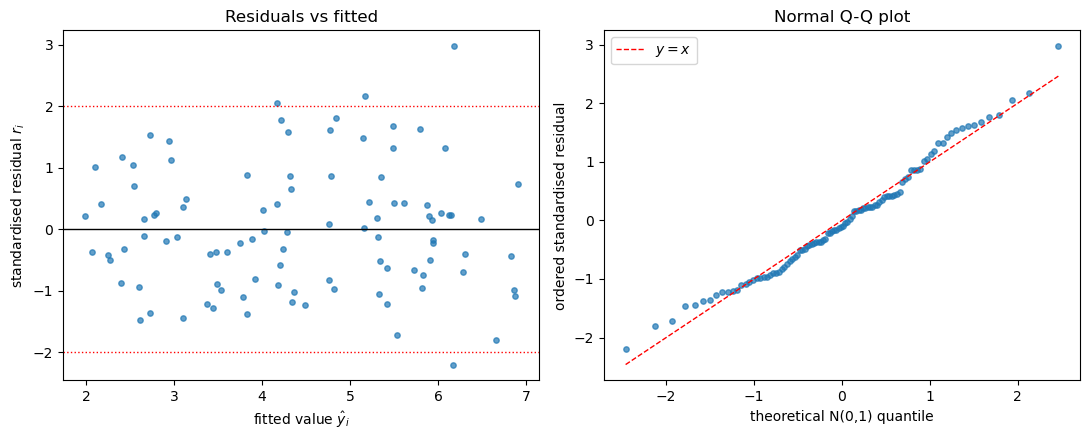

Max leverage = 0.0422  (average leverage p/n = 0.0200)
Points with |r_i| > 2: 4 of 100 (about 4.6 expected under normality)


In [12]:
standardised = residuals / (s * np.sqrt(1 - leverage))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.scatter(y_hat, standardised, s=15, alpha=0.7)
ax1.axhline(0, color='k', lw=1)
ax1.axhline(2, color='r', ls=':', lw=1)
ax1.axhline(-2, color='r', ls=':', lw=1)
ax1.set(xlabel='fitted value $\\hat y_i$', ylabel='standardised residual $r_i$',
        title='Residuals vs fitted')

(theoretical_q, ordered_r), _ = stats.probplot(standardised, dist='norm')
ax2.scatter(theoretical_q, ordered_r, s=15, alpha=0.7)
ax2.plot(theoretical_q, theoretical_q, 'r--', lw=1, label='$y = x$')
ax2.set(xlabel='theoretical N(0,1) quantile', ylabel='ordered standardised residual',
        title='Normal Q-Q plot')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Max leverage = {leverage.max():.4f}  (average leverage p/n = {p / n:.4f})')
print(f'Points with |r_i| > 2: {np.sum(np.abs(standardised) > 2)} of {n} '
      f'(about {2 * stats.norm.sf(2) * n:.1f} expected under normality)')

## 11. A Monte Carlo check of the theory

Every result above concerns the behaviour of estimators over **repeated sampling**. We can check them directly. We keep the design $\mathbf X$ fixed (we conditioned on it throughout), draw $R = 10{,}000$ fresh error vectors, refit OLS to each simulated $\mathbf y$, and compare the empirical behaviour with the theory:

| Claim | Theory |
|---|---|
| Unbiasedness | $\mathbb E[\hat{\boldsymbol\beta}] = \boldsymbol\beta$ |
| Covariance | $\operatorname{Var}(\hat{\boldsymbol\beta}) = \sigma^2(\mathbf X^\top\mathbf X)^{-1}$ |
| Unbiased variance estimator | $\mathbb E[s^2] = \sigma^2$ |
| Coverage | 95% CIs contain $\beta_j$ in 95% of samples |

`np.linalg.lstsq` accepts a matrix of right-hand sides. All $R$ regressions are therefore fitted in a single vectorised call, with each column of `Y` being one simulated data set.

In [13]:
R = 10_000

E = rng.normal(0, sigma_true, size=(n, R))
Y = (X @ beta_true)[:, None] + E                       # n x R: one data set per column

B_hat, *_ = np.linalg.lstsq(X, Y, rcond=None)          # p x R: one estimate per column
resid_sim = Y - X @ B_hat
s2_sim = np.sum(resid_sim ** 2, axis=0) / df_resid
se_sim = np.sqrt(s2_sim[None, :] * np.diag(XtX_inv)[:, None])

covered = np.abs(B_hat - beta_true[:, None]) <= t_crit * se_sim
coverage = covered.mean(axis=1)

print('Mean of beta_hat over simulations:', B_hat.mean(axis=1), '  true:', beta_true)
print('\nEmpirical covariance of beta_hat:')
print(np.cov(B_hat))
print('Theoretical sigma^2 (X^T X)^{-1}:')
print(sigma_true ** 2 * XtX_inv)
print(f'\nMean of s^2 = {s2_sim.mean():.4f}   (true sigma^2 = {sigma_true ** 2})')
print(f'95% CI coverage: intercept {coverage[0]:.4f}, slope {coverage[1]:.4f}')

Mean of beta_hat over simulations: [2.00075057 0.49986566]   true: [2.  0.5]

Empirical covariance of beta_hat:
[[ 0.042817   -0.0066481 ]
 [-0.0066481   0.00134857]]
Theoretical sigma^2 (X^T X)^{-1}:
[[ 0.04196141 -0.00656671]
 [-0.00656671  0.00134918]]

Mean of s^2 = 1.0010   (true sigma^2 = 1.0)
95% CI coverage: intercept 0.9504, slope 0.9504


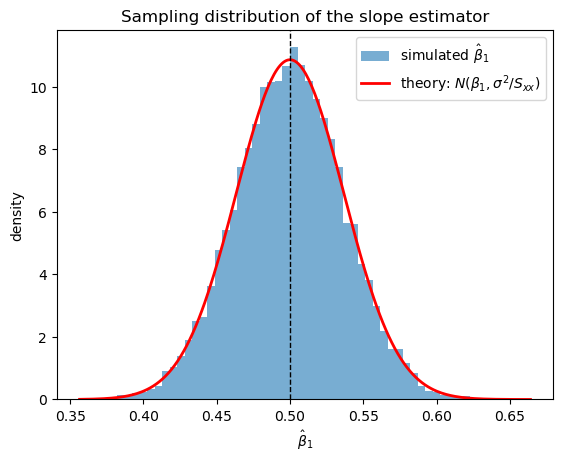

In [14]:
slope_sd = sigma_true * np.sqrt(XtX_inv[1, 1])
grid = np.linspace(B_hat[1].min(), B_hat[1].max(), 300)

fig, ax = plt.subplots()
ax.hist(B_hat[1], bins=60, density=True, alpha=0.6, label='simulated $\\hat\\beta_1$')
ax.plot(grid, stats.norm.pdf(grid, beta_true[1], slope_sd), 'r', lw=2,
        label='theory: $N(\\beta_1, \\sigma^2/S_{xx})$')
ax.axvline(beta_true[1], color='k', ls='--', lw=1)
ax.set(xlabel='$\\hat\\beta_1$', ylabel='density', title='Sampling distribution of the slope estimator')
ax.legend()
plt.show()

## Summary

| Quantity | Formula | Distribution under A1–A5 |
|---|---|---|
| OLS estimator | $\hat{\boldsymbol\beta} = (\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y$ | $\mathcal N_p\big(\boldsymbol\beta,\ \sigma^2(\mathbf X^\top\mathbf X)^{-1}\big)$ |
| Error variance | $s^2 = \mathrm{RSS}/(n-p)$ | $(n-p)s^2/\sigma^2 \sim \chi^2_{n-p}$, independent of $\hat{\boldsymbol\beta}$ |
| Standard error | $\operatorname{SE}(\hat\beta_j) = s\sqrt{[(\mathbf X^\top\mathbf X)^{-1}]_{jj}}$ | — |
| $t$-statistic | $(\hat\beta_j - \beta_j)/\operatorname{SE}(\hat\beta_j)$ | $t_{n-p}$ |
| CI for $\beta_j$ | $\hat\beta_j \pm t_{n-p,1-\alpha/2}\operatorname{SE}(\hat\beta_j)$ | coverage $1-\alpha$ |
| $R^2$ | $1 - \mathrm{RSS}/\mathrm{TSS}$ | — |
| Overall $F$ | $\dfrac{\mathrm{ESS}/(p-1)}{\mathrm{RSS}/(n-p)}$ | $F_{p-1,n-p}$ under $H_0$ |
| CI for mean response | $\mathbf x_0^\top\hat{\boldsymbol\beta} \pm t\, s\sqrt{\mathbf x_0^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_0}$ | coverage $1-\alpha$ |
| Prediction interval | $\mathbf x_0^\top\hat{\boldsymbol\beta} \pm t\, s\sqrt{1+\mathbf x_0^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_0}$ | coverage $1-\alpha$ |

Everything in this notebook is written in matrix form, so it extends unchanged to **multiple regression**. Add further predictor columns to $\mathbf X$, and $p$, the degrees of freedom and all of the formulas update automatically.

**Exercises**

1. Add a second predictor $x_2$ to the simulation and to $\mathbf X$. Check that the coverage of every coefficient's CI stays near 95%.
2. Generate errors with variance proportional to $x_i^2$ (violating A4). How do the residual plot and the CI coverage in Section 11 change?
3. Replace the normal errors with $t_3$ errors (violating A5). Is $\hat{\boldsymbol\beta}$ still unbiased? Does the Q–Q plot detect the change?